In [59]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import os

base_path = "/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset"

for folder in ["train", "valid", "test"]:
    folder_path = os.path.join(base_path, folder)

    print(f"\n{folder.upper()} CLASSES:")
    classes = os.listdir(folder_path)

    print("Number of classes:", len(classes))
    print("Classes:", classes)
    

/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/valid/Dermatitis/Bacteria4_png_jpg.rf.42e25758ac3c6a6bbcf036a21e2a36a1.jpg
/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/valid/Dermatitis/53_jpg.rf.80b9bef7fbf04517df4c6b579cc0847c.jpg
/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/valid/Dermatitis/Hot-Spot-on-_Chance_-How-to-treat-a-dog-that-you-can_t-touch_-000624_png_jpg.rf.866d22ce7d959e60512aeccd1836f921.jpg
/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/valid/Dermatitis/1000010697_x16_jpg.rf.f7efcdcfd7a9dba8ad55b5a6b9f50099.jpg
/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/valid/Dermatitis/hotspot-110-_jpg.rf.47ae5c004128f0140a400149e3a93465.jpg
/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/valid/Dermatitis/HOT-SPOT-IN-DOG-HOW-vet-treated-symptom-prevention_-flea-bite-moist-eczema_dog-itching-000478_png_jpg.rf.0ae9284e37aaed2386f04bb6ec5a6

In [60]:
import os

base_path = "/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset"

for split in ['train', 'valid', 'test']:
    total_images = 0

    for cls in os.listdir(os.path.join(base_path, split)):
        cls_path = os.path.join(base_path, split, cls)
        total_images += len(os.listdir(cls_path))

    print(f"{split.upper()} Images: {total_images}")
    

TRAIN Images: 3022
VALID Images: 860
TEST Images: 433


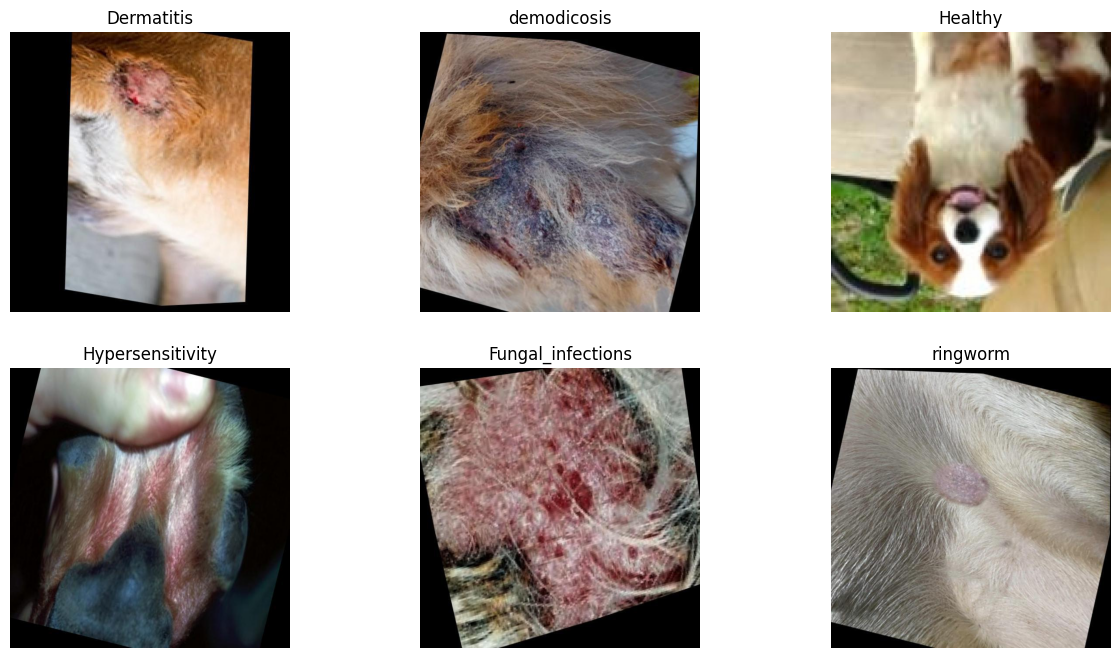

In [61]:
import matplotlib.pyplot as plt
import os
from PIL import Image

base_path = "/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/train"

classes = os.listdir(base_path)

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(base_path, cls))[0]
    img_path = os.path.join(base_path, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [62]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/train"
valid_dir = "/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/valid"
test_dir = "/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Classes:", train_generator.class_indices)

Found 3022 images belonging to 6 classes.
Found 860 images belonging to 6 classes.
Found 433 images belonging to 6 classes.
Classes: {'Dermatitis': 0, 'Fungal_infections': 1, 'Healthy': 2, 'Hypersensitivity': 3, 'demodicosis': 4, 'ringworm': 5}


In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = cnn_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.2905 - loss: 1.7530 - val_accuracy: 0.3628 - val_loss: 1.5440
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.3666 - loss: 1.5486 - val_accuracy: 0.4047 - val_loss: 1.4690
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.3895 - loss: 1.4710 - val_accuracy: 0.4093 - val_loss: 1.4834
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.4193 - loss: 1.4367 - val_accuracy: 0.4488 - val_loss: 1.3899
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.4232 - loss: 1.4139 - val_accuracy: 0.4349 - val_loss: 1.3449
Epoch 6/10
73/95 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.4455 - loss: 1.3498

In [ ]:
print(type(train_generator))
print(type(valid_generator))
print(type(cnn_model))

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

base_path = "/kaggle/input/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset"

train_dir = base_path + "/train"
valid_dir = base_path + "/valid"
test_dir = base_path + "/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
history = cnn_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = cnn_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

In [ ]:
base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
base_model.summary()

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [ ]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

In [ ]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_generator)

print("MobileNet Test Accuracy:", test_accuracy)
print("MobileNet Test Loss:", test_loss)
